# 03 — Classification Experiments
**DiabetScope-AI: Diabetes Binary Classification**

**Objective:** Train and compare 5 classification models on the Pima Indians Diabetes dataset to predict binary outcome (diabetic vs non-diabetic).

**Models:**
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbors (KNN)
4. Random Forest Classifier
5. XGBoost Classifier

**Evaluation Priority (Medical Context):**
- **Recall (Sensitivity)** — #1 priority: catch as many diabetic patients as possible
- **F1-Score** — balance between Precision and Recall
- **MCC (Matthews Correlation)** — best single metric for imbalanced data
- **ROC-AUC** — discrimination across all thresholds
- **Precision** — of flagged patients, how many are truly diabetic
- **Accuracy** — overall correctness (least informative on imbalanced data)

**Outputs:**
- Individual model `.pkl` files → `models/classification/`
- Best model → `models/classification/best_classifier.pkl`
- Fitted scaler → `scalers/classification_scaler.pkl`
- Performance report → `reports/classification_results.json`
- Comparison tables and plots inline

In [1]:
# ──────────────────────────────────────────────────────────────────
# Standard libraries
# ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
from datetime import datetime

# ──────────────────────────────────────────────────────────────────
# Preprocessing
# ──────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# ──────────────────────────────────────────────────────────────────
# Classification models
# ──────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ──────────────────────────────────────────────────────────────────
# Evaluation metrics
# ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

# ──────────────────────────────────────────────────────────────────
# Serialization
# ──────────────────────────────────────────────────────────────────
import joblib

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All imports successful')
print(f'📅 Experiment started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ All imports successful
📅 Experiment started: 2026-02-02 19:55:02


## 2. Load Preprocessed Data

We load `diabetes_clean.csv` which already has:
- Missing values imputed (median)
- Outliers capped (IQR winsorization)
- Interaction features engineered (`Age_Glucose`, `BMI_Age`, `Glucose_BMI`)

**Shape:** 768 rows × 12 columns (11 features + 1 target)

In [2]:
# ──────────────────────────────────────────────────────────────────
# Load the fully preprocessed CSV
# ──────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/diabetes_clean.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nTarget distribution:')
print(df['Outcome'].value_counts())
print(f'  Non-diabetic: {(df["Outcome"]==0).sum()} ({(df["Outcome"]==0).mean()*100:.1f}%)')
print(f'  Diabetic:     {(df["Outcome"]==1).sum()} ({(df["Outcome"]==1).mean()*100:.1f}%)')
print(f'  Imbalance ratio: {(df["Outcome"]==0).sum() / (df["Outcome"]==1).sum():.2f} : 1')

df.head()

Dataset shape: (768, 12)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Age_Glucose_Interaction', 'BMI_Age_Interaction', 'Glucose_BMI_Interaction', 'Outcome']

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
  Non-diabetic: 500 (65.1%)
  Diabetic:     268 (34.9%)
  Imbalance ratio: 1.87 : 1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Age_Glucose_Interaction,BMI_Age_Interaction,Glucose_BMI_Interaction,Outcome
0,6.0,148.0,72.0,35.0,125.000,33.6,0.627,50.0,7400.0,1680.0,4972.8,1
1,1.0,85.0,66.0,29.0,125.000,26.6,0.351,31.0,2635.0,824.6,2261.0,0
2,8.0,183.0,64.0,29.0,125.000,23.3,0.672,32.0,5856.0,745.6,4263.9,1
3,1.0,89.0,66.0,23.0,112.875,28.1,0.167,21.0,1869.0,590.1,2500.9,0
4,0.0,137.0,40.0,35.0,135.875,43.1,1.200,33.0,4521.0,1422.3,5904.7,1


## 3. Train-Test Split & Scaling

**Strategy:**
- **80/20 split** (614 train, 154 test)
- **Stratified** — preserves 65/35 class ratio in both sets
- **StandardScaler** fit on train only (prevent data leakage)
  - Mean = 0, Std = 1 for each feature
  - Critical for distance-based models (KNN, Logistic Regression)
  - Tree-based models don't need it but we scale anyway for fair comparison

In [3]:
# ──────────────────────────────────────────────────────────────────
# Separate features and target
# ──────────────────────────────────────────────────────────────────
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print(f'Features shape: {X.shape}')
print(f'Feature names: {list(X.columns)}')

# ──────────────────────────────────────────────────────────────────
# Stratified split (same class ratio in train and test)
# ──────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # ← preserves 65/35 ratio
)

print(f'\nTrain set: {X_train.shape[0]} samples')
print(f'  Diabetic: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test set:  {X_test.shape[0]} samples')
print(f'  Diabetic: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

# ──────────────────────────────────────────────────────────────────
# Scale features: fit on train ONLY (prevent data leakage)
# ──────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled  = scaler.transform(X_test)       # transform only

print(f'\n✅ Scaling complete')
print(f'   Mean of scaled train features: {X_train_scaled.mean(axis=0).round(3).tolist()[:3]} ...')
print(f'   Std  of scaled train features: {X_train_scaled.std(axis=0).round(3).tolist()[:3]} ...')

# Save scaler for deployment
os.makedirs('../scalers', exist_ok=True)
joblib.dump(scaler, '../scalers/classification_scaler.pkl')
print(f'\n💾 Scaler saved → scalers/classification_scaler.pkl')

Features shape: (768, 11)
Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Age_Glucose_Interaction', 'BMI_Age_Interaction', 'Glucose_BMI_Interaction']

Train set: 614 samples
  Diabetic: 214 (34.9%)
Test set:  154 samples
  Diabetic: 54 (35.1%)

✅ Scaling complete
   Mean of scaled train features: [-0.0, -0.0, -0.0] ...
   Std  of scaled train features: [1.0, 1.0, 1.0] ...

💾 Scaler saved → scalers/classification_scaler.pkl


## 4. Evaluation Function

Single function to compute all 6 metrics for any classifier.
Reused across all 5 models for consistency.

def evaluate_classifier(name, model, X_test, y_test, use_scaled=True):
    """
    Train evaluation: compute all metrics + save model.
    
    Parameters:
        name       : model name (for labeling)
        model      : fitted classifier
        X_test     : test features (scaled or raw depending on use_scaled)
        y_test     : test labels
        use_scaled : if True, use X_test_scaled; else use raw X_test
    
    Returns:
        dict with all metrics
    """
    X_eval = X_test_scaled if use_scaled else X_test.values
    
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    
    results = {
        'Model':     name,
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'MCC':       matthews_corrcoef(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
        'Precision': precision_score(y_test, y_pred),
        'Accuracy':  accuracy_score(y_test, y_pred),
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }
    
    return results

print('✅ Evaluation function ready')

---
# MODEL 1: Logistic Regression

**Theory:**
- Fits a linear decision boundary: w₁x₁ + w₂x₂ + ... + b = 0
- Passes result through sigmoid → probability ∈ [0, 1]
- If P(diabetic) ≥ 0.5 → predict 1

**Strengths:**
- Fast to train
- Outputs calibrated probabilities
- Good baseline for linear separability

**Hyperparameters:**
- `max_iter=1000` — more iterations for convergence
- `random_state=42` — reproducibility
- `C=1.0` — inverse regularization (neutral)

**Scaling requirement:** ✅ YES — needs scaled features

In [5]:
# ──────────────────────────────────────────────────────────────────
# Train Logistic Regression
# ──────────────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_results = evaluate_classifier('Logistic Regression', lr, X_test, y_test, use_scaled=True)

print('=== Logistic Regression Results ===')
print(f"Recall:    {lr_results['Recall']:.4f}")
print(f"F1-Score:  {lr_results['F1-Score']:.4f}")
print(f"MCC:       {lr_results['MCC']:.4f}")
print(f"ROC-AUC:   {lr_results['ROC-AUC']:.4f}")
print(f"Precision: {lr_results['Precision']:.4f}")
print(f"Accuracy:  {lr_results['Accuracy']:.4f}")

# Save model
os.makedirs('../models/classification', exist_ok=True)
joblib.dump(lr, '../models/classification/logistic_regression.pkl')
print('\n💾 Model saved → models/classification/logistic_regression.pkl')

=== Logistic Regression Results ===
Recall:    0.5185
F1-Score:  0.5600
MCC:       0.3529
ROC-AUC:   0.8085
Precision: 0.6087
Accuracy:  0.7143

💾 Model saved → models/classification/logistic_regression.pkl


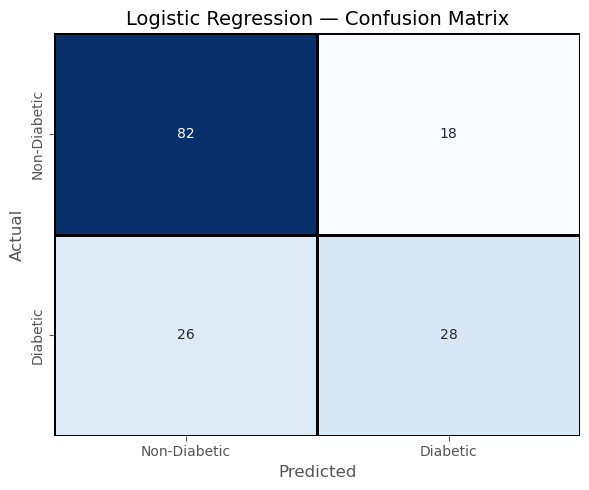

FN (diabetic missed): 26 | TP (diabetic caught): 28


In [6]:
# ──────────────────────────────────────────────────────────────────
# Confusion Matrix
# ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_results['y_pred'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=ax, cbar=False, linewidths=1, linecolor='black')

ax.set_title('Logistic Regression — Confusion Matrix', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"FN (diabetic missed): {cm[1,0]} | TP (diabetic caught): {cm[1,1]}")

---
# MODEL 2: Decision Tree Classifier

**Theory:**
- Recursively splits data on feature thresholds
- Example: "If Glucose > 127.5 → right branch; else → left"
- Builds until leaves are pure or stopping criteria met

**Strengths:**
- Highly interpretable (can visualize the tree)
- Captures non-linear patterns
- No scaling needed (threshold-based)

**Hyperparameters:**
- `max_depth=5` — limit depth to prevent overfitting
- `min_samples_split=10` — node needs ≥10 samples to split
- `min_samples_leaf=5` — each leaf must have ≥5 samples
- `random_state=42`

**Scaling requirement:** ❌ NO — uses raw features

In [8]:
# ──────────────────────────────────────────────────────────────────
# Train Decision Tree
# ──────────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)

dt_results = evaluate_classifier('Decision Tree', dt, X_test, y_test, use_scaled=False)

print('=== Decision Tree Results ===')
print(f"Recall:    {dt_results['Recall']:.4f}")
print(f"F1-Score:  {dt_results['F1-Score']:.4f}")
print(f"MCC:       {dt_results['MCC']:.4f}")
print(f"ROC-AUC:   {dt_results['ROC-AUC']:.4f}")
print(f"Precision: {dt_results['Precision']:.4f}")
print(f"Accuracy:  {dt_results['Accuracy']:.4f}")

# Save model
joblib.dump(dt, '../models/classification/decision_tree.pkl')
print('\n💾 Model saved → models/classification/decision_tree.pkl')

=== Decision Tree Results ===
Recall:    0.4630
F1-Score:  0.5319
MCC:       0.3406
ROC-AUC:   0.7764
Precision: 0.6250
Accuracy:  0.7143

💾 Model saved → models/classification/decision_tree.pkl


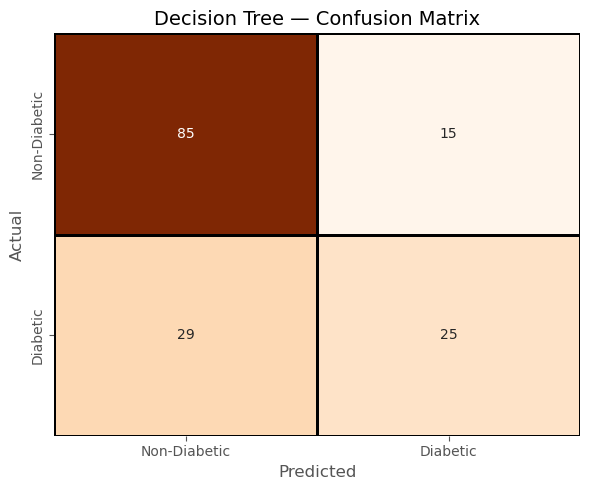

FN (diabetic missed): 29 | TP (diabetic caught): 25


In [9]:
# ──────────────────────────────────────────────────────────────────
# Confusion Matrix
# ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, dt_results['y_pred'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=ax, cbar=False, linewidths=1, linecolor='black')

ax.set_title('Decision Tree — Confusion Matrix', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"FN (diabetic missed): {cm[1,0]} | TP (diabetic caught): {cm[1,1]}")

---
# MODEL 3: K-Nearest Neighbors (KNN)

**Theory:**
- Instance-based learning — no explicit training phase
- For prediction: find K most similar patients (Euclidean distance)
- Majority vote among K neighbors → prediction

**Strengths:**
- Captures local non-linear patterns
- Simple and intuitive
- No assumptions about data distribution

**Hyperparameters:**
- `n_neighbors=5` — classic default
- `weights='distance'` — closer neighbors have more influence
- Too few neighbors (1-2) → noisy; too many (20+) → over-smoothed

**Scaling requirement:** ✅ YES — distance-based, needs scaled features

In [10]:
# ──────────────────────────────────────────────────────────────────
# Train KNN
# ──────────────────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train_scaled, y_train)

knn_results = evaluate_classifier('KNN (k=5)', knn, X_test, y_test, use_scaled=True)

print('=== KNN Results ===')
print(f"Recall:    {knn_results['Recall']:.4f}")
print(f"F1-Score:  {knn_results['F1-Score']:.4f}")
print(f"MCC:       {knn_results['MCC']:.4f}")
print(f"ROC-AUC:   {knn_results['ROC-AUC']:.4f}")
print(f"Precision: {knn_results['Precision']:.4f}")
print(f"Accuracy:  {knn_results['Accuracy']:.4f}")

# Save model
joblib.dump(knn, '../models/classification/knn.pkl')
print('\n💾 Model saved → models/classification/knn.pkl')

=== KNN Results ===
Recall:    0.5556
F1-Score:  0.5769
MCC:       0.3623
ROC-AUC:   0.7756
Precision: 0.6000
Accuracy:  0.7143

💾 Model saved → models/classification/knn.pkl


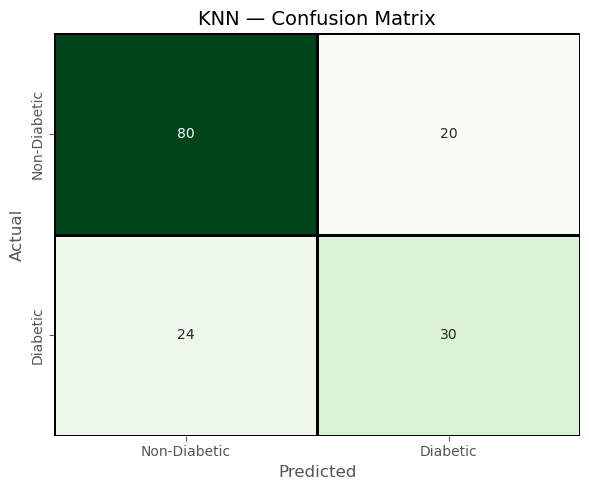

FN (diabetic missed): 24 | TP (diabetic caught): 30


In [11]:
# ──────────────────────────────────────────────────────────────────
# Confusion Matrix
# ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, knn_results['y_pred'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=ax, cbar=False, linewidths=1, linecolor='black')

ax.set_title('KNN — Confusion Matrix', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"FN (diabetic missed): {cm[1,0]} | TP (diabetic caught): {cm[1,1]}")

---
# MODEL 4: Random Forest Classifier

**Theory:**
- Ensemble of many decision trees
- Each tree trained on:
  1. Random subset of rows (bootstrap)
  2. Random subset of features
- Final prediction = majority vote across all trees

**Strengths:**
- Reduces overfitting vs single tree
- Handles interactions automatically
- Built-in feature importance
- Robust to outliers

**Hyperparameter Tuning (GridSearchCV):**
- `n_estimators`: [100, 200, 300]
- `max_depth`: [8, 12, 15, None]
- `min_samples_split`: [5, 10]
- `min_samples_leaf`: [2, 5]
- 5-fold StratifiedCV, optimizing for **Recall**

**Scaling requirement:** ❌ NO — tree-based

In [24]:
# ──────────────────────────────────────────────────────────────────
# GridSearchCV for Random Forest
# ──────────────────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [8, 12, 15, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf':  [2, 5]
}

rf_base = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring='recall',  # optimize for medical priority
    cv=cv,
    n_jobs=-1,
    refit=True
)

print('⏳ Running Random Forest GridSearchCV...')
print(f'   {len(rf_param_grid["n_estimators"]) * len(rf_param_grid["max_depth"]) * len(rf_param_grid["min_samples_split"]) * len(rf_param_grid["min_samples_leaf"])} combinations × 5 folds')

rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_

print(f'\n✅ Best parameters:')
print(json.dumps(rf_grid.best_params_, indent=2))
print(f'Best CV Recall: {rf_grid.best_score_:.4f}')

rf_results = evaluate_classifier('Random Forest', rf, X_test, y_test, use_scaled=False)

print('\n=== Random Forest Test Results ===')
print(f"Recall:    {rf_results['Recall']:.4f}")
print(f"F1-Score:  {rf_results['F1-Score']:.4f}")
print(f"MCC:       {rf_results['MCC']:.4f}")
print(f"ROC-AUC:   {rf_results['ROC-AUC']:.4f}")
print(f"Precision: {rf_results['Precision']:.4f}")
print(f"Accuracy:  {rf_results['Accuracy']:.4f}")

# Save model
joblib.dump(rf, '../models/classification/random_forest.pkl')
print('\n💾 Model saved → models/classification/random_forest.pkl')

⏳ Running Random Forest GridSearchCV...
   48 combinations × 5 folds

✅ Best parameters:
{
  "max_depth": 8,
  "min_samples_leaf": 2,
  "min_samples_split": 5,
  "n_estimators": 100
}
Best CV Recall: 0.6076

=== Random Forest Test Results ===
Recall:    0.6667
F1-Score:  0.6792
MCC:       0.5112
ROC-AUC:   0.8270
Precision: 0.6923
Accuracy:  0.7792

💾 Model saved → models/classification/random_forest.pkl


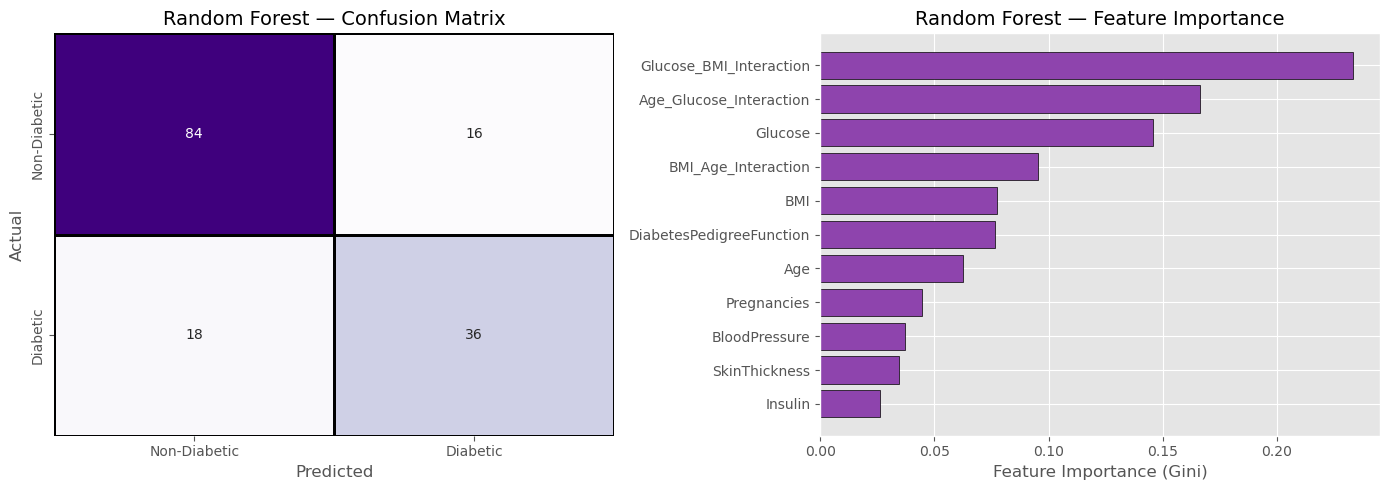

FN (diabetic missed): 18 | TP (diabetic caught): 36


In [13]:
# ──────────────────────────────────────────────────────────────────
# Confusion Matrix + Feature Importance
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confusion Matrix
cm = confusion_matrix(y_test, rf_results['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=axes[0], cbar=False, linewidths=1, linecolor='black')
axes[0].set_title('Random Forest — Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Right: Feature Importance
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)
axes[1].barh(X.columns[sorted_idx], importances[sorted_idx],
             color='#8e44ad', edgecolor='black')
axes[1].set_xlabel('Feature Importance (Gini)')
axes[1].set_title('Random Forest — Feature Importance', fontsize=14)

plt.tight_layout()
plt.show()

print(f"FN (diabetic missed): {cm[1,0]} | TP (diabetic caught): {cm[1,1]}")

---
# MODEL 5: XGBoost Classifier

**Theory:**
- Gradient boosting — sequential ensemble
- Each tree fixes errors of previous trees
- Key difference from Random Forest:
  - RF: trees are INDEPENDENT (parallel, vote)
  - XGB: trees are SEQUENTIAL (each corrects the last)

**Strengths:**
- State-of-the-art on tabular data
- Regularization controls overfitting
- `scale_pos_weight` handles class imbalance
  - Set to neg/pos ratio ≈ 1.87
  - Upweights minority class (diabetic patients)

**Hyperparameter Tuning (GridSearchCV):**
- `n_estimators`: [100, 200, 300]
- `max_depth`: [3, 5, 7]
- `learning_rate`: [0.05, 0.1, 0.2]
- `subsample`: [0.8]
- `colsample_bytree`: [0.8]
- 5-fold StratifiedCV, optimizing for **Recall**

**Scaling requirement:** ❌ NO — tree-based

In [25]:
# ──────────────────────────────────────────────────────────────────
# Compute scale_pos_weight (class imbalance correction)
# ──────────────────────────────────────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'Class imbalance correction:')
print(f'  Negatives: {neg_count}, Positives: {pos_count}')
print(f'  scale_pos_weight = {scale_pos_weight:.4f}')

# ──────────────────────────────────────────────────────────────────
# GridSearchCV for XGBoost
# ──────────────────────────────────────────────────────────────────
xgb_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1, 0.2],
    'subsample':        [0.8],
    'colsample_bytree': [0.8]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    refit=True
)

n_combos = 1
for v in xgb_param_grid.values():
    n_combos *= len(v)

print(f'\n⏳ Running XGBoost GridSearchCV...')
print(f'   {n_combos} combinations × 5 folds')

xgb_grid.fit(X_train, y_train)
xgb_model = xgb_grid.best_estimator_

print(f'\n✅ Best parameters:')
print(json.dumps(xgb_grid.best_params_, indent=2))
print(f'Best CV Recall: {xgb_grid.best_score_:.4f}')

xgb_results = evaluate_classifier('XGBoost', xgb_model, X_test, y_test, use_scaled=False)

print('\n=== XGBoost Test Results ===')
print(f"Recall:    {xgb_results['Recall']:.4f}")
print(f"F1-Score:  {xgb_results['F1-Score']:.4f}")
print(f"MCC:       {xgb_results['MCC']:.4f}")
print(f"ROC-AUC:   {xgb_results['ROC-AUC']:.4f}")
print(f"Precision: {xgb_results['Precision']:.4f}")
print(f"Accuracy:  {xgb_results['Accuracy']:.4f}")

# Save model
joblib.dump(xgb_model, '../models/classification/xgboost.pkl')
print('\n💾 Model saved → models/classification/xgboost.pkl')

Class imbalance correction:
  Negatives: 400, Positives: 214
  scale_pos_weight = 1.8692

⏳ Running XGBoost GridSearchCV...
   27 combinations × 5 folds

✅ Best parameters:
{
  "colsample_bytree": 0.8,
  "learning_rate": 0.05,
  "max_depth": 3,
  "n_estimators": 100,
  "subsample": 0.8
}
Best CV Recall: 0.7524

=== XGBoost Test Results ===
Recall:    0.7778
F1-Score:  0.6885
MCC:       0.4975
ROC-AUC:   0.8281
Precision: 0.6176
Accuracy:  0.7532

💾 Model saved → models/classification/xgboost.pkl


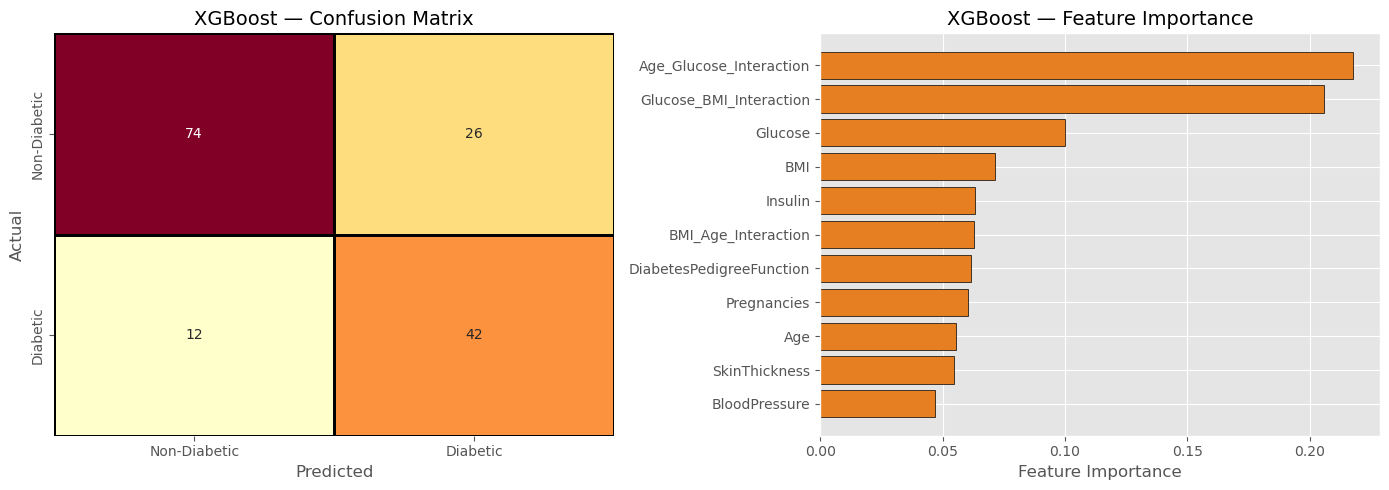

FN (diabetic missed): 12 | TP (diabetic caught): 42


In [15]:
# ──────────────────────────────────────────────────────────────────
# Confusion Matrix + Feature Importance
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confusion Matrix
cm = confusion_matrix(y_test, xgb_results['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            ax=axes[0], cbar=False, linewidths=1, linecolor='black')
axes[0].set_title('XGBoost — Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Right: Feature Importance
importances = xgb_model.feature_importances_
sorted_idx = np.argsort(importances)
axes[1].barh(X.columns[sorted_idx], importances[sorted_idx],
             color='#e67e22', edgecolor='black')
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('XGBoost — Feature Importance', fontsize=14)

plt.tight_layout()
plt.show()

print(f"FN (diabetic missed): {cm[1,0]} | TP (diabetic caught): {cm[1,1]}")

---
## 5. Model Comparison

Compare all 5 models on the same test set.

**Metric Priority (Medical Context):**
1. **Recall** — minimize FN (diabetic patients missed)
2. **F1-Score** — balanced Precision/Recall
3. **MCC** — best single metric for imbalanced data
4. **ROC-AUC** — discrimination across thresholds
5. **Precision** — of flagged patients, % truly diabetic
6. **Accuracy** — overall correctness

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Build comparison table
# ──────────────────────────────────────────────────────────────────
all_results = [lr_results, dt_results, knn_results, rf_results, xgb_results]

comparison = []
for r in all_results:
    comparison.append({
        'Model':     r['Model'],
        'Recall':    round(r['Recall'], 4),
        'F1-Score':  round(r['F1-Score'], 4),
        'MCC':       round(r['MCC'], 4),
        'ROC-AUC':   round(r['ROC-AUC'], 4),
        'Precision': round(r['Precision'], 4),
        'Accuracy':  round(r['Accuracy'], 4)
    })

df_comparison = pd.DataFrame(comparison).set_index('Model')

# Add ★ to best value per column
display_df = df_comparison.copy().astype(str)
for col in df_comparison.columns:
    best_idx = df_comparison[col].idxmax()
    display_df.loc[best_idx, col] = display_df.loc[best_idx, col] + ' ★'

print('='*85)
print('  CLASSIFICATION MODEL COMPARISON')
print('  ★ = best score in each column')
print('='*85)
print(display_df.to_string())
print('='*85)

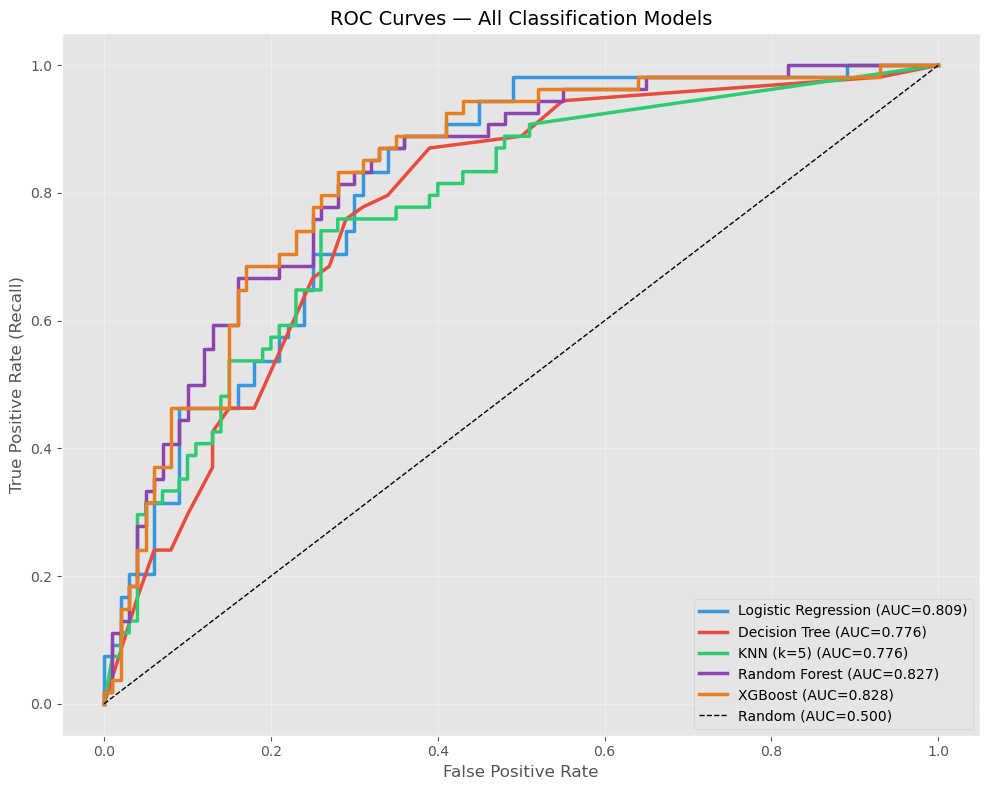

In [17]:
# ──────────────────────────────────────────────────────────────────
# Combined ROC Curves
# ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

colors = {
    'Logistic Regression': '#3498db',
    'Decision Tree':       '#e74c3c',
    'KNN (k=5)':           '#2ecc71',
    'Random Forest':       '#8e44ad',
    'XGBoost':             '#e67e22'
}

for r in all_results:
    name = r['Model']
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    auc = r['ROC-AUC']
    ax.plot(fpr, tpr, color=colors[name], linewidth=2.5,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Classification Models', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Model Selection & Export

**Selection Rule:** Recall → F1-Score → MCC  
(Medical priority: minimize False Negatives)

In [18]:
# ──────────────────────────────────────────────────────────────────
# Select best model
# ──────────────────────────────────────────────────────────────────
ranked = sorted(all_results,
                key=lambda r: (r['Recall'], r['F1-Score'], r['MCC']),
                reverse=True)
best = ranked[0]

print('🏆 BEST CLASSIFIER')
print(f"   Model: {best['Model']}")
print(f"   Recall:    {best['Recall']:.4f}")
print(f"   F1-Score:  {best['F1-Score']:.4f}")
print(f"   MCC:       {best['MCC']:.4f}")
print(f"   ROC-AUC:   {best['ROC-AUC']:.4f}")
print(f"   Precision: {best['Precision']:.4f}")
print(f"   Accuracy:  {best['Accuracy']:.4f}")

# ──────────────────────────────────────────────────────────────────
# Save best model
# ──────────────────────────────────────────────────────────────────
if best['Model'] == 'Logistic Regression':
    best_model_obj = lr
elif best['Model'] == 'Decision Tree':
    best_model_obj = dt
elif best['Model'] == 'KNN (k=5)':
    best_model_obj = knn
elif best['Model'] == 'Random Forest':
    best_model_obj = rf
else:
    best_model_obj = xgb_model

joblib.dump(best_model_obj, '../models/classification/best_classifier.pkl')
print('\n💾 Best model saved → models/classification/best_classifier.pkl')

🏆 BEST CLASSIFIER
   Model: XGBoost
   Recall:    0.7778
   F1-Score:  0.6885
   MCC:       0.4975
   ROC-AUC:   0.8281
   Precision: 0.6176
   Accuracy:  0.7532

💾 Best model saved → models/classification/best_classifier.pkl


In [19]:
# ──────────────────────────────────────────────────────────────────
# Save results JSON
# ──────────────────────────────────────────────────────────────────
report = {
    'experiment': 'classification',
    'dataset': {
        'source': 'Pima Indians Diabetes',
        'total_samples': 768,
        'train_samples': len(y_train),
        'test_samples': len(y_test),
        'features': 11
    },
    'selected_model': best['Model'],
    'selection_criteria': 'Recall > F1-Score > MCC',
    'all_models': []
}

for r in all_results:
    report['all_models'].append({
        'model': r['Model'],
        'recall': float(r['Recall']),
        'f1_score': float(r['F1-Score']),
        'mcc': float(r['MCC']),
        'roc_auc': float(r['ROC-AUC']),
        'precision': float(r['Precision']),
        'accuracy': float(r['Accuracy'])
    })

os.makedirs('../reports', exist_ok=True)
with open('../reports/classification_results.json', 'w') as f:
    json.dump(report, f, indent=2)

print('📄 Results report saved → reports/classification_results.json')

📄 Results report saved → reports/classification_results.json


---
## ✅ Experiment Complete

**Outputs:**
- ✅ 5 individual models → `models/classification/*.pkl`
- ✅ Best model → `models/classification/best_classifier.pkl`
- ✅ Scaler → `scalers/classification_scaler.pkl`
- ✅ Results → `reports/classification_results.json`

**Next Steps:**
- Run `04_regression_experiments.ipynb` for glucose prediction
- Compare classification vs regression in `05_model_evaluation.ipynb`
- Deploy best models in Flask/FastAPI backend